# Habitat 居家双任务：固定 MPC 与元认知 MPC

本实验在 ReplicaCAD 居家场景中使用 Fetch 机器人完成两个独立任务：**抓取桌上的水杯**、**打开厨房抽屉**。导航是两个任务共同的前置过程。比较对象为固定规划预算的 model-based RL baseline，以及使用相同世界模型结构、任务目标和动作能力的元认知 MPC。

元认知模块先读取预测误差、搜索改善、碰撞和执行进展，再预测阶段可靠性并分配后续搜索计算。它区分监测分数、概率校准和控制选择；不会用“信心超过 85%”作为通用执行开关。世界模型的更新次数和 FIFO replay 规则保持固定。


**预算：**默认三种子共 720 个训练 episode、6360 个验证/测试 episode，另有环境检查、每种子 240 个几何 reset 和 30 个共同轨迹监测诊断 episode。pilot 指每个模型的训练预算较小，完整比较仍有较多评估。若先检查流程，可在 Cell 5 将 `SEEDS` 设为 `[0]`；正式比较再使用多个种子。所有数字均为计划预算，未预填任何实验成绩。

## Cell 1 · 展开源码并设置路径

只需上传这个 notebook。下面的压缩内容已经包含独立 Python 源码、测试和中文说明，无需另外上传源码 ZIP。`code_meta_v2` 存源码，`outputs_meta_v2` 存实验结果；重新执行本单元会恢复内嵌源码。现有 Habitat 安装和数据可复用。

In [4]:
import base64, io, json, os, subprocess, sys, zipfile
from pathlib import Path
from IPython.display import display, Image, Video

WORK = Path('/content/habitat_cup_demo')
CODE = WORK / 'code_meta_v2'
ENV = WORK / 'habitat-env'
PYTHON = ENV / 'bin/python'
DATA = WORK / 'data'
OUTPUT_ROOT = WORK / 'outputs_meta_v2'
CODE.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TASKS = ('pick_cup', 'open_drawer')
TASK_LABELS = {'pick_cup': '取杯', 'open_drawer': '开抽屉'}
DOMAIN_LABELS = ['A 原始环境', 'B 通道受阻', 'C 操作环境拥挤']
AGENTS = ('baseline', 'metacognitive')
PAYLOAD = '...'
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PAYLOAD))) as archive:
    archive.extractall(CODE)
print('源码：', CODE)
print('环境：', ENV)
print('数据：', DATA)

源码： /content/habitat_cup_demo/code_meta_v2
环境： /content/habitat_cup_demo/habitat-env
数据： /content/habitat_cup_demo/data


## Cell 2 · 安装或复用 Habitat



In [5]:
probe_code = (
    "import habitat_sim, habitat, torch, numpy; "
    "assert habitat_sim.__version__ == '0.3.3'; "
    "assert numpy.__version__ == '1.26.4'"
)
child_env = os.environ.copy()
child_env.pop('PYTHONPATH', None)
child_env.pop('PYTHONHOME', None)
child_env['MPLBACKEND'] = 'Agg'
ready = PYTHON.exists() and subprocess.run(
    [str(PYTHON), '-c', probe_code], env=child_env, capture_output=True
).returncode == 0
if ready:
    print('复用已安装的 Habitat 0.3.3 环境。')
else:
    subprocess.run([sys.executable, str(CODE / 'bootstrap.py'), '--prefix', str(ENV)],
                   env=child_env, check=True)
print('Habitat Python：', PYTHON)

Habitat Python： /content/habitat_cup_demo/habitat-env/bin/python


## Cell 3 · 准备场景数据与运行入口

下载或验证 ReplicaCAD、Fetch 资产。`run_habitat` 在独立环境中执行每个命令，把完整输出保留为日志；控制台只省略重复插件提示。发生错误时检查最后的异常与日志路径，插件重复提示通常不是程序退出的原因。

In [6]:
def run_habitat(arguments, tag='run'):
    """Run one Habitat subprocess and preserve its complete diagnostic log."""
    env = os.environ.copy()
    env.pop('PYTHONPATH', None)
    env.pop('PYTHONHOME', None)
    env.update(PYTHONUNBUFFERED='1', MPLBACKEND='Agg', HABITAT_SIM_LOG='error',
               MAGNUM_LOG='quiet', OMP_NUM_THREADS='1', OPENBLAS_NUM_THREADS='1')
    logs = WORK / 'logs_meta_v2'
    logs.mkdir(parents=True, exist_ok=True)
    log_path = logs / (tag + '.log')
    command = [str(PYTHON)] + [str(arg) for arg in arguments]
    print('运行：', ' '.join(command))
    with log_path.open('w') as log:
        proc = subprocess.Popen(command, cwd=str(CODE), env=env,
                                stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        try:
            for line in proc.stdout:
                log.write(line)
                log.flush()
                if not line.startswith('PluginManager::Manager: duplicate'):
                    print(line, end='')
            result = proc.wait()
        except BaseException:
            proc.terminate()
            try:
                proc.wait(timeout=5)
            except subprocess.TimeoutExpired:
                proc.kill()
                proc.wait()
            raise
    if result:
        tail = '\n'.join(log_path.read_text(errors='replace').splitlines()[-60:])
        raise RuntimeError(f'进程退出码 {result}；日志：{log_path}\n最后 60 行：\n{tail}')
    return log_path

run_habitat(['download_assets.py', '--data', DATA], 'assets')

运行： /content/habitat_cup_demo/habitat-env/bin/python download_assets.py --data /content/habitat_cup_demo/data
Assets 25/677
Assets 50/677
Assets 75/677
Assets 100/677
Assets 125/677
Assets 150/677
Assets 175/677
Assets 200/677
Assets 225/677
Assets 250/677
Assets 275/677
Assets 300/677
Assets 325/677
Assets 350/677
Assets 375/677
Assets 400/677
Assets 425/677
Assets 450/677
Assets 475/677
Assets 500/677
Assets 525/677
Assets 550/677
Assets 575/677
Assets 600/677
Assets 625/677
Assets 650/677
Assets 675/677
Assets 677/677
ASSETS READY: 677 verified files, 192.1 MB


PosixPath('/content/habitat_cup_demo/logs_meta_v2/assets.log')

## Cell 4 · 检查代码与任务接口

先执行回归检查，再用**未训练的先验参考 MPC**在一个固定布局、固定种子下检查两任务 × A/B/C。这里验证环境与动作接口是否可工作。

`CHECK` 后两个数字为成功标记和步数。A 条件失败会停止；B/C 的策略失败会保留并显示，应结合导航成功、碰撞和抽屉开度判断困难在哪一段。参考控制器成功不能证明所有测试场景都可完成，参考控制器失败也不能证明学习后的模型一定失败。

成功标准：取杯后抬高至少 12 cm、保持 5 步；抽屉实际拉开至少 18 cm、保持 5 步。使用辅助抓握、运动学控制及新增障碍的几何碰撞近似，详见源码 `ENVIRONMENT_zh.md`。

In [7]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 6)
run_habitat(['-m', 'unittest', 'discover', '-s', 'tests', '-v'], 'code_checks')
CHECK_DIR = WORK / 'outputs_meta_v2' / 'environment_check'
run_habitat(['-m', 'cup_baseline.run', 'smoke', '--data', DATA,
             '--out', CHECK_DIR], 'environment_check')
check = json.loads((CHECK_DIR / 'environment_check.json').read_text())
display(pd.DataFrame(check['rows'])[
    ['task', 'domain', 'success', 'steps', 'nav_success', 'collision_steps',
     'manipulation_collision_steps', 'drawer_open_m']
])
print(check['note'])

运行： /content/habitat_cup_demo/habitat-env/bin/python -m unittest discover -s tests -v
test_all_unreached_and_single_reached_statistics_are_explicit (test_aggregate.AggregateTests) ... ok
test_complete_seed_coverage_and_continual_protocol_guard (test_aggregate.AggregateTests) ... 对比数据： /tmp/tmpinpu97lt/0/comparison/comparison.json 状态： basic_complete_continual_pending
对比数据： /tmp/tmpinpu97lt/1/comparison/comparison.json 状态： basic_complete_continual_pending
对比数据： /tmp/tmpinpu97lt/0/comparison/comparison.json 状态： complete
对比数据： /tmp/tmpinpu97lt/1/comparison/comparison.json 状态： complete
多 seed 汇总： /tmp/tmpinpu97lt/aggregate/aggregate.json 训练 seed 数： 2
ok
test_duplicate_seed_and_changed_protocol_rejected (test_aggregate.AggregateTests) ... 对比数据： /tmp/tmplnsz_7dk/a/comparison/comparison.json 状态： basic_complete_continual_pending
对比数据： /tmp/tmplnsz_7dk/b/comparison/comparison.json 状态： basic_complete_continual_pending
ok
test_seed_means_pairing_and_missing_thresholds (test_aggregate.AggregateTest

,task,domain,success,steps,nav_success,collision_steps,manipulation_collision_steps,drawer_open_m
0,pick_cup,A_clear,1,35,1,4,0,0.000000
1,open_drawer,A_clear,1,198,1,14,0,0.214745
2,pick_cup,B_passage_blocked,1,37,1,0,0,0.000000
3,open_drawer,B_passage_blocked,0,240,0,240,0,0.000000
4,pick_cup,C_workspace_clutter,0,240,1,4,0,0.000000
5,open_drawer,C_workspace_clutter,0,240,0,217,0,0.000000


Reference-controller smoke checks, not trained scores; failed tasks remain visible.


## Cell 5 · 统一设置 pilot、种子与结果位置

这里集中设置整套实验参数。`SEEDS` 是**独立训练种子**；每个种子下两组使用相同任务、布局与初始条件，实际动作轨迹允许不同。测试 episode 的 bootstrap 区间无法代替训练种子之间的变化，因此默认直接运行三个训练种子。

默认每组、每种子：基础训练 60 个 episode，两任务各 30 个；其中前 4 个先验采集 episode 计入这 60 个。每次基础验证每任务 10 个，最终 seen/unseen 每任务各 20 个。seen/unseen 是相同任务在训练布局/未见布局中的评估。

'smoke'    →   4 episodes：两任务各 2 次，用于快速检查流程。
'pilot'    →  60 episodes：两任务各 30 次，用于初步比较。
'research' → 300 episodes：两任务各 150 次，用于较大规模实验。
preset 还会同时调整验证/测试数量、模型更新次数和 MPC 搜索预算。

持续学习：每组每阶段 20 个训练 episode，两任务各 10 个；每 4 个总训练 episode 验证一次。基础训练与持续学习的模型更新、FIFO replay 和训练样本分别计数。



In [8]:
PRESET = 'pilot'
DYNAMICS = 'learned'
SEEDS = [0,1]             # 一次 pilot 直接包含多个独立训练种子。
EPISODES = None              # None 使用 preset；pilot 为每组每种子 60 个。
REPLAY_LIMIT = 4096          # 世界模型保存的 transition 上限，按 FIFO 淘汰。
RESUME = True
META_COMPUTE_WEIGHT = 0.10   # 训练前固定；不得根据正式测试结果调参。
META_STEP_WEIGHT = 0.05
PHASE_EPISODES = 20          # 每个 A/B/C 阶段的两任务合计训练 episode。
CL_EVAL_N = 20               # 每个任务、每个条件的保留测试 episode。
CL_VALIDATION_N = 10         # 每个任务的阶段适应验证 episode。
CL_CHECK_EVERY = 4
SHADOW_N = 5                 # 共同轨迹诊断：每任务/条件 5 个，共 30 个/seed。
GENERATION_VERSION = 'passage_v2'
USE_DRIVE = True

if not SEEDS or len(SEEDS) != len(set(SEEDS)) or any(type(s) is not int or s < 0 for s in SEEDS):
    raise ValueError('SEEDS 必须是非空、不重复的非负整数列表。')
if EPISODES is not None and (EPISODES < 2 or EPISODES % 2):
    raise ValueError('EPISODES 必须是大于等于 2 的偶数。')
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_ROOT = Path('/content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2')
else:
    OUTPUT_ROOT = WORK / 'outputs_meta_v2'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIRS = {
    seed: OUTPUT_ROOT / f'meta_v2_{DYNAMICS}_{PRESET}_seed{seed}' for seed in SEEDS
}
RUN_DIRS_BY_SEED = {
    seed: {agent: experiment / agent for agent in AGENTS}
    for seed, experiment in EXPERIMENT_DIRS.items()
}
CL_DIRS_BY_SEED = {
    seed: {agent: experiment / f'continual_{agent}_{GENERATION_VERSION}' for agent in AGENTS}
    for seed, experiment in EXPERIMENT_DIRS.items()
}
AGGREGATE_DIR = OUTPUT_ROOT / f'aggregate_{DYNAMICS}_{PRESET}'
print('训练种子：', SEEDS)
print('实验结果：', OUTPUT_ROOT)
print('跨种子汇总：', AGGREGATE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
训练种子： [0, 1]
实验结果： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2
跨种子汇总： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/aggregate_learned_pilot


## Cell 6 · 每个种子训练两组模型

baseline 使用固定 CEM 规划预算；元认知在共享动作能力下分配搜索批次，并可回退到固定 MPC。世界模型为三个 MLP 的集成，学习真实动作后的状态变化；两组都使用 MPC 在这个模型中预测候选动作序列，然后执行第一个动作并重新规划。

两组世界模型使用相同结构、初始种子和更新规则，但各自收集轨迹并训练，训练后的权重可能不同。因此闭环比较衡量整个系统的效果；它不能把差异全部归因于监测头。Cell 8 另用共同轨迹诊断概率校准。

元认知的阶段成功、碰撞和预测误差监督来自实际训练反馈；概率校准使用训练内部保留数据。诊断头与 Q 头共享表示，调控由 Q 值选择；校准概率本身不作为执行阈值，改善校准不保证行为改变。调控只学习实际执行选项的结果，不为未执行选项伪造反馈。所有初始/追加搜索、回退、监测前向和训练更新分别计费。世界模型固定更新、4096 条 FIFO replay 保持一致；元认知额外的监督记录与校准记录单独报告。

验证/测试冻结两个模型的参数、校准参数和所有训练缓冲区。episode 内可以累积误差历史并调整计算，episode 结束后清空局部历史。冻结不是禁止 agent 思考或重新规划，而是防止测试结果变成训练数据。

In [ ]:
def train_agent(agent, seed, run_dir):
    command = ['-m', 'cup_baseline.run', 'train', '--data', DATA, '--out', run_dir,
               '--preset', PRESET, '--dynamics', DYNAMICS, '--seed', seed,
               '--agent', agent, '--replay-limit', REPLAY_LIMIT,
               '--meta-compute-weight', META_COMPUTE_WEIGHT,
               '--meta-step-weight', META_STEP_WEIGHT]
    if EPISODES is not None:
        command += ['--episodes', EPISODES]
    if RESUME and (run_dir / 'checkpoint.pt').exists():
        command += ['--resume']
    run_habitat(command, f'train_meta_v2_{agent}_seed{seed}')

for seed in SEEDS:
    for agent in AGENTS:
        print(f'基础训练：seed={seed}, agent={agent}')
        train_agent(agent, seed, RUN_DIRS_BY_SEED[seed][agent])
print('基础训练完成。下一单元执行必测的 A→B→C 持续学习。')

基础训练：seed=0, agent=baseline
运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.run train --data /content/habitat_cup_demo/data --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/baseline --preset pilot --dynamics learned --seed 0 --agent baseline --replay-limit 4096 --meta-compute-weight 0.1 --meta-step-weight 0.05
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
validation/pick_cup: 10 episodes, SR=0.900
validation/open_drawer: 10 episodes, SR=0.700
train 1/60: task=pick_cup, success=1, steps=36, loss=0.055797761275122565
train 2/60: task=open_drawer, success=1, steps=174, loss=0.02399680563636745
train 3/60: task=pic

## Cell 7 · A→B→C 持续学习

从各组自己的基础 checkpoint 出发，依次训练 A 原始环境、B 通道受阻、C 操作环境拥挤。B 增加会导致绕行的纸箱；C 在杯子或抽屉把手的操作区域增加物体。B/C 各自相对 A 变化，不把两种变化累积叠加，也不改变动作增益。

每个种子先检查本协议全部不同初始环境。默认 240 次纯几何 reset 不执行策略、不学习、不计入训练样本；场景生成失败会停止并保存诊断，不记作 agent 失败，也不根据策略成功率筛选环境。B 若必须重新采样起点，会记录该变化；两组使用匹配几何。几何检查通过并不证明机械臂任意姿态都可达。

每组、每种子默认 60 个持续学习训练 episode、840 个评估 episode。阶段内以冻结验证曲线衡量适应；阶段结束冻结评估全部 A/B/C，形成保留矩阵；推理与更新代价分别记录。世界模型、元认知模型和 replay 在训练 episode 间持续保留。

In [10]:
def check_continual_geometry(seed):
    run_habitat(['-m', 'cup_baseline.run', 'check_domains', '--data', DATA,
                 '--out', EXPERIMENT_DIRS[seed] / f'generation_check_{GENERATION_VERSION}',
                 '--checkpoint', RUN_DIRS_BY_SEED[seed]['baseline'] / 'checkpoint.pt',
                 '--phase-episodes', PHASE_EPISODES, '--eval-n', CL_EVAL_N,
                 '--validation-n', CL_VALIDATION_N, '--check-every', CL_CHECK_EVERY],
                f'geometry_meta_v2_seed{seed}_{GENERATION_VERSION}')

def run_continual(agent, seed):
    run_habitat(['-m', 'cup_baseline.run', 'continual', '--data', DATA,
                 '--out', CL_DIRS_BY_SEED[seed][agent],
                 '--checkpoint', RUN_DIRS_BY_SEED[seed][agent] / 'checkpoint.pt',
                 '--phase-episodes', PHASE_EPISODES, '--eval-n', CL_EVAL_N,
                 '--validation-n', CL_VALIDATION_N, '--check-every', CL_CHECK_EVERY],
                f'continual_meta_v2_{agent}_seed{seed}_{GENERATION_VERSION}')

for seed in SEEDS:
    check_continual_geometry(seed)
    for agent in AGENTS:
        print(f'持续学习：seed={seed}, agent={agent}')
        run_continual(agent, seed)
print('所有指定种子的两组持续学习已完成。')

运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.run check_domains --data /content/habitat_cup_demo/data --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/generation_check_passage_v2 --checkpoint /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/baseline/checkpoint.pt --phase-episodes 20 --eval-n 20 --validation-n 10 --check-every 4
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
GEOMETRY 1/240 pick_cup A_clear v3_sc0_staging_00 seed=750000
GEOMETRY 2/240 pick_cup A_clear v3_sc0_staging_01 seed=750001
GEOMETRY 3/240 pick_cup A_clear v3_sc1_staging_00 seed=750002
GEOMETRY 4/240 p

## Cell 8 · 分种子比较与跨种子汇总

生成可追溯的 CSV、JSON 和 PNG，不预设哪组获胜。每种子的两组配置、测试初始条件与持续学习几何必须匹配；只汇总 Cell 5 明确指定且已完成的种子。

- **样本效率 N85**：验证成功率首次达到 85%，且下一检查点仍达标；未达标显示 `>预算`。单位为两任务合计的训练 episode。N85=0 表示初始验证已经达标。未达标值不能替换成预算或当作零参与普通平均。
- **计算代价**：NN FLOPs、批量/样本前向次数、实际环境步数。FLOPs 是计算代理量，非实测电耗；不包含物理、渲染、IK、几何与所有软件开销。每成功成本包含失败尝试的计算。
- **泛化**：分别看 seen/unseen 成功率；gap=seen−unseen。负值表示这批 unseen 布局表现更高；gap 接近零不自动等于泛化更好。
- **持续学习**：适应 N85/AUC、阶段后表现、保留矩阵、BWT/遗忘与阶段成本。冻结初始 SR 是整个持续学习开始前的基础模型；它不是每个阶段开始前的表现。沿同一矩阵列向下看才能观察变化。
- **不确定性**：单 seed 的配对 episode bootstrap 只反映该训练模型下的测试抽样；跨 seed 表按训练种子统计均值、样本标准差和数量。三个 seed 仍属于小规模实验，不把测试 episode 当独立训练重复。

本单元还先做**共同轨迹监测诊断**：固定 baseline 世界模型/规划器执行，从基础训练 checkpoint 读取的冻结元监测器只观察，不改变动作或学习。每种子默认 30 个 episode，报告同一轨迹上的原始/校准概率质量及独立成本；这些不计训练样本，也不并入下面基础/持续学习的成本表。该诊断读取 baseline 策略的状态分布，不能直接证明元认知闭环策略的反事实收益。

监测预测质量与任务表现分别保存。概率校准不保证控制有效；Brier/ECE 也不等于人类实验中的内在元认知噪声。应结合搜索选择、误差与执行轨迹分析机制。

运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.run shadow --data /content/habitat_cup_demo/data --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/shadow --checkpoint /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/baseline/checkpoint.pt --monitor-checkpoint /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/metacognitive/checkpoint.pt --n 5
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
SHADOW A_clear/pick_cup: 5 frozen episodes
SHADOW A_clear/open_drawer: 5 frozen episodes
SHADOW B_passage_blocked/pick_cup: 5 frozen episodes
SHADOW B_pas

,episodes,environment_steps,policy_nn_flops,observer_nn_flops,total_nn_flops,wall_seconds
0,30,3202,138557558784,34788862258,173346421042,191.84054


,task,domain,episodes,success_rate,n,raw_phase_n,raw_phase_brier,raw_phase_ece,raw_phase_discrimination_auc,raw_phase_high_confidence_n,raw_phase_high_confidence_failures,phase_n,phase_brier,phase_ece,phase_discrimination_auc,phase_high_confidence_n,phase_high_confidence_failures,raw_collision_n,raw_collision_brier,raw_collision_ece,raw_collision_discrimination_auc,raw_collision_high_confidence_n,raw_collision_high_confidence_failures,collision_n,collision_brier,collision_ece,collision_discrimination_auc,collision_high_confidence_n,collision_high_confidence_failures,prediction_error_mae,prediction_error_rmse
0,pick_cup,A_clear,5,1.0,371,371,0.039036,0.150396,NaN,242,0,371,0.039036,0.150396,NaN,242,0,371,0.124063,0.088639,0.862690,61,20,371,0.133421,0.113271,0.862690,88,24,0.144599,0.197116
1,open_drawer,A_clear,5,1.0,212,212,0.004934,0.053378,NaN,205,0,212,0.004934,0.053378,NaN,205,0,212,0.021447,0.025639,0.979094,0,0,212,0.021942,0.020717,0.979094,1,1,0.093090,0.097655
2,pick_cup,B_passage_blocked,5,0.6,787,787,0.301502,0.342899,0.820888,207,55,787,0.301502,0.342899,0.820888,207,55,787,0.133659,0.131578,0.915087,307,6,787,0.123297,0.100805,0.915087,329,11,0.266541,0.312695
3,open_drawer,B_passage_blocked,5,0.4,828,828,0.292102,0.447417,0.943338,153,57,828,0.292102,0.447417,0.943338,153,57,828,0.197303,0.272861,0.969083,387,2,828,0.190313,0.235636,0.969083,452,3,0.408000,0.451180
4,pick_cup,C_workspace_clutter,5,0.8,599,599,0.328159,0.378132,0.326109,411,202,599,0.328159,0.378132,0.326109,411,202,599,0.096104,0.054523,0.931857,88,11,599,0.095776,0.057062,0.931857,126,22,0.143892,0.185805
5,open_drawer,C_workspace_clutter,5,0.8,405,405,0.157364,0.220629,0.931061,167,26,405,0.157364,0.220629,0.931061,167,26,405,0.048157,0.049432,0.968841,205,7,405,0.044469,0.022277,0.968841,217,7,0.298143,0.370460


运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.compare --baseline /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/baseline --metacognitive /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/metacognitive --baseline-cl /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/continual_baseline_passage_v2 --metacognitive-cl /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/continual_metacognitive_passage_v2 --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/comparison
对比数据： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0/comparison/comparison.json 状态： complete

种子 0：基础指标


,agent,task,split,n,success_pct,steps,steps_success_only,nav_success_pct,collision_steps,manipulation_collision_steps,nn_gflops_episode,nn_gflops_per_success,nn_batch_forwards,meta_gflops_episode,n85_total_episodes,n85_train_steps,generalization_gap_pp
0,baseline,pick_cup,seen,20,85.0,83.55,55.941176,90.0,48.35,0.0,3.615392,4.253402,4010.40,0.000000,0,0,-15.0
1,metacognitive,pick_cup,seen,20,90.0,58.85,38.722222,90.0,31.15,0.0,2.852249,3.169166,5774.90,0.000830,0,0,-10.0
2,baseline,open_drawer,seen,20,85.0,78.60,50.117647,95.0,4.30,0.0,3.401194,4.001405,3772.80,0.000000,40,2535,-10.0
3,metacognitive,open_drawer,seen,20,85.0,78.15,49.588235,85.0,4.25,0.0,3.907594,4.597169,7912.85,0.001139,10,827,-10.0
4,baseline,pick_cup,unseen,20,100.0,51.30,51.300000,100.0,15.85,0.0,2.219863,2.219863,2462.40,0.000000,0,0,-15.0
5,metacognitive,pick_cup,unseen,20,100.0,47.85,47.850000,100.0,9.25,0.0,2.482050,2.482050,4456.55,0.000532,0,0,-10.0
6,baseline,open_drawer,unseen,20,95.0,55.75,46.052632,100.0,8.30,0.0,2.412425,2.539394,2676.00,0.000000,40,2535,-10.0
7,metacognitive,open_drawer,unseen,20,95.0,49.55,39.526316,95.0,2.85,0.0,2.519560,2.652169,4844.30,0.000648,10,827,-10.0


...

,agent,task,final_average_success,backward_transfer,average_forgetting
0,baseline,pick_cup,0.833333,-0.025,0.050
1,baseline,open_drawer,0.666667,0.025,0.025
2,metacognitive,pick_cup,0.783333,-0.025,0.025
3,metacognitive,open_drawer,0.700000,0.100,0.025


continual_costs.csv


,agent,domain,training_episodes,steps,total_gflops,meta_inference_gflops,meta_update_gflops,world_update_gflops
0,baseline,A_clear,20,1296,69.062418,0.000000,0.000000,12.981658
1,baseline,B_passage_blocked,20,3509,164.823779,0.000000,0.000000,12.981658
2,baseline,C_workspace_clutter,20,3193,151.149767,0.000000,0.000000,12.981658
3,metacognitive,A_clear,20,1220,72.633318,0.015432,0.550586,12.981658
4,metacognitive,B_passage_blocked,20,3691,186.032924,0.054129,0.552931,12.981658
5,metacognitive,C_workspace_clutter,20,2950,142.706987,0.041085,0.554360,12.981658


continual_paired.csv


,after_phase,domain,task,n,success_difference_pp,baseline_success_pct,metacognitive_success_pct,steps_difference,nn_gflops_episode_difference,episode_bootstrap_ci95,note
0,A_clear,A_clear,pick_cup,20,5.0,95.0,100.0,-8.20,0.131833,"[0.0, 15.0]",Paired episode bootstrap conditional on this t...
1,A_clear,A_clear,open_drawer,20,-5.0,90.0,85.0,3.80,0.548955,"[-20.0, 10.0]",Paired episode bootstrap conditional on this t...
2,A_clear,B_passage_blocked,pick_cup,20,-10.0,35.0,25.0,15.30,1.098941,"[-30.0, 10.0]",Paired episode bootstrap conditional on this t...
3,A_clear,B_passage_blocked,open_drawer,20,0.0,40.0,40.0,-6.35,-0.110916,"[-30.0, 30.0]",Paired episode bootstrap conditional on this t...
4,A_clear,C_workspace_clutter,pick_cup,20,0.0,80.0,80.0,-17.45,-0.014210,"[0.0, 0.0]",Paired episode bootstrap conditional on this t...
5,A_clear,C_workspace_clutter,open_drawer,20,-15.0,60.0,45.0,23.15,2.547963,"[-30.0, 0.0]",Paired episode bootstrap conditional on this t...
6,B_passage_blocked,A_clear,pick_cup,20,0.0,100.0,100.0,0.50,0.155648,"[0.0, 0.0]",Paired episode bootstrap conditional on this t...
7,B_passage_blocked,A_clear,open_drawer,20,5.0,90.0,95.0,-6.30,-0.096161,"[0.0, 15.0]",Paired episode bootstrap conditional on this t...
8,B_passage_blocked,B_passage_blocked,pick_cup,20,-5.0,65.0,60.0,2.35,0.567817,"[-30.0, 20.0]",Paired episode bootstrap conditional on this t...
9,B_passage_blocked,B_passage_blocked,open_drawer,20,0.0,40.0,40.0,16.70,2.210212,"[-25.0, 25.0]",Paired episode bootstrap conditional on this t...


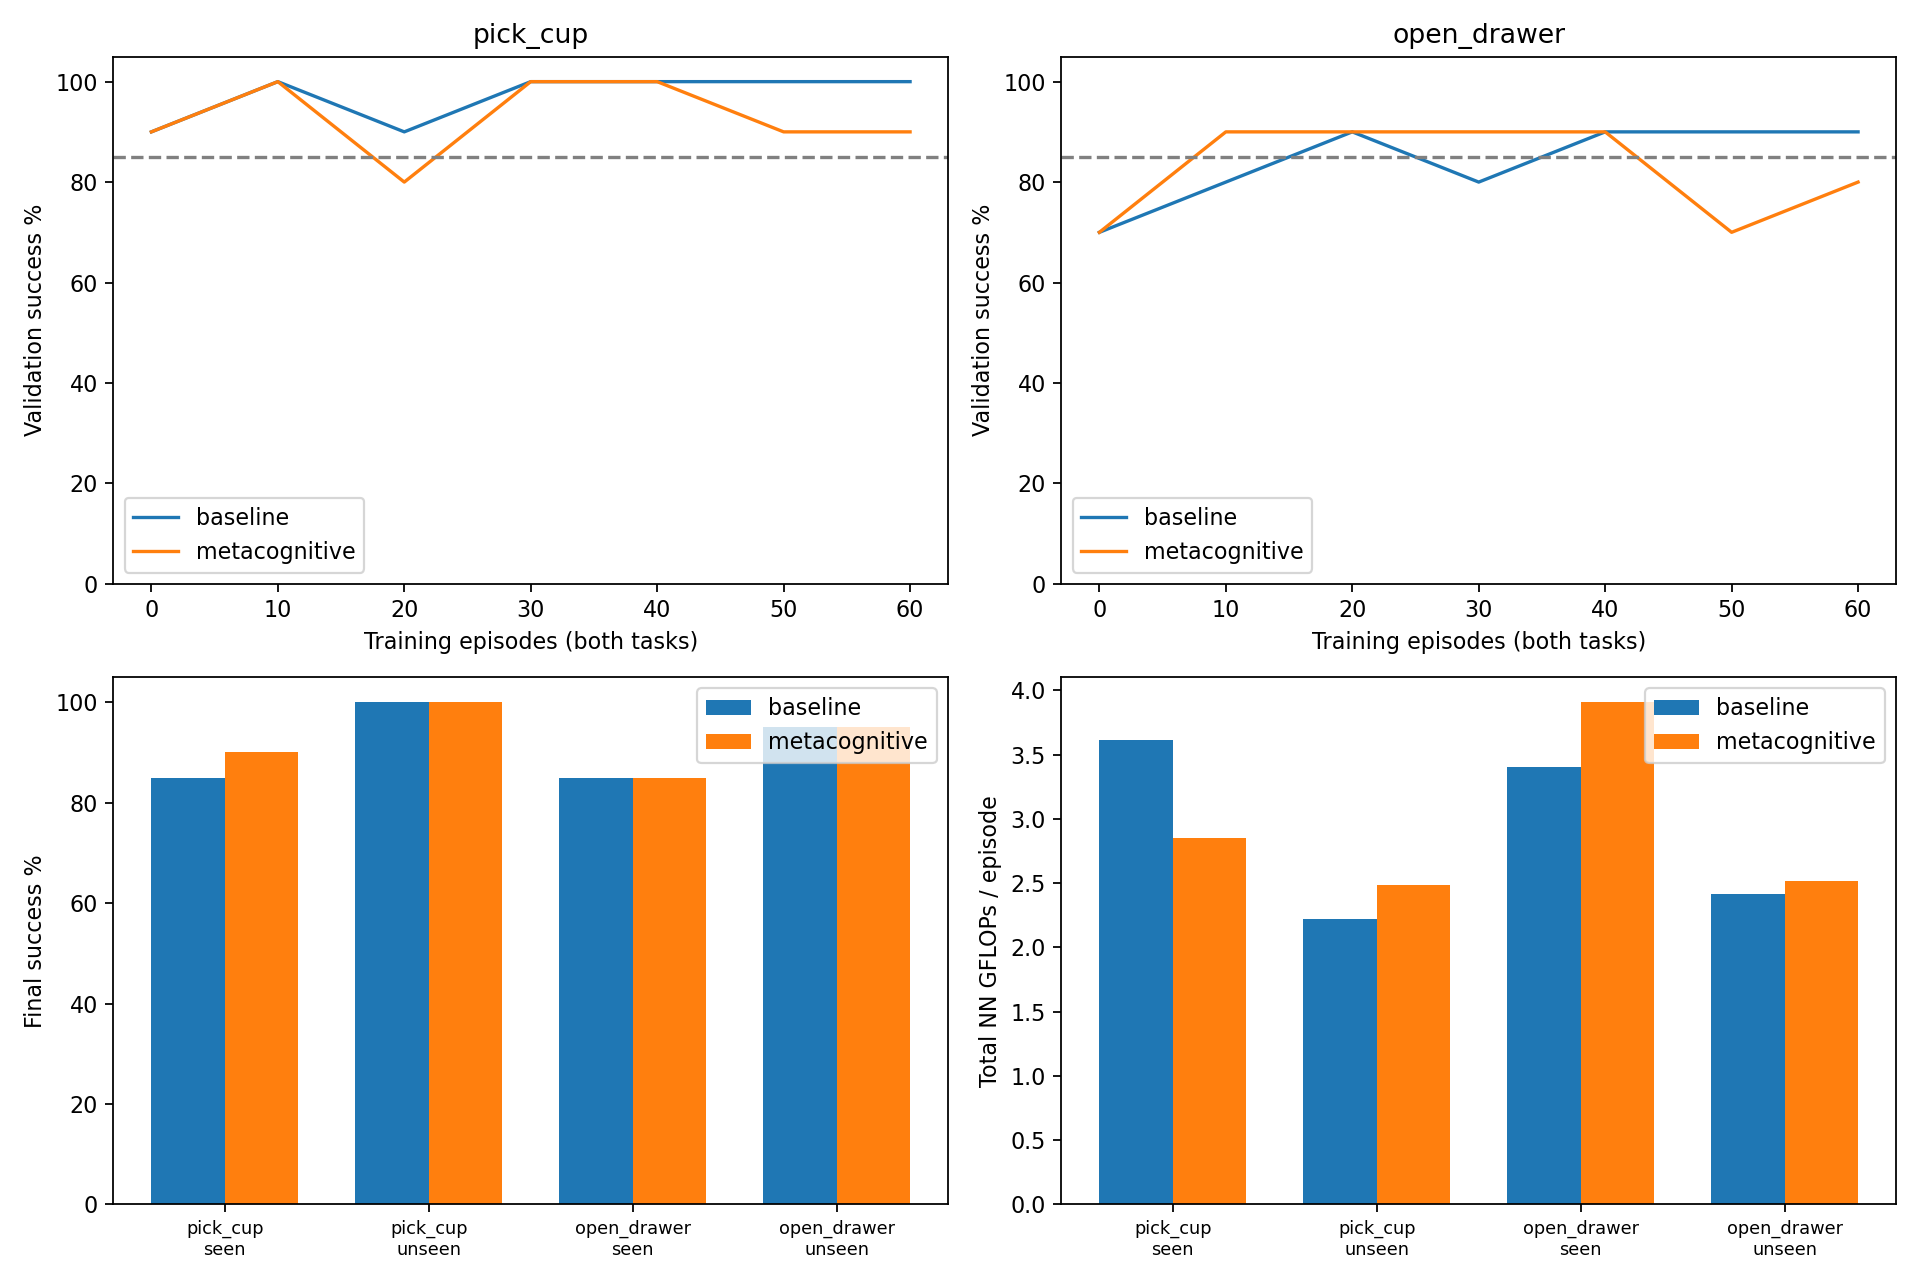

运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.run shadow --data /content/habitat_cup_demo/data --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/shadow --checkpoint /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/baseline/checkpoint.pt --monitor-checkpoint /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/metacognitive/checkpoint.pt --n 5
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
SHADOW A_clear/pick_cup: 5 frozen episodes
SHADOW A_clear/open_drawer: 5 frozen episodes
SHADOW B_passage_blocked/pick_cup: 5 frozen episodes
SHADOW B_pas

,episodes,environment_steps,policy_nn_flops,observer_nn_flops,total_nn_flops,wall_seconds
0,30,2355,101906012160,25586436795,127492448955,150.527678


,task,domain,episodes,success_rate,n,raw_phase_n,raw_phase_brier,raw_phase_ece,raw_phase_discrimination_auc,raw_phase_high_confidence_n,raw_phase_high_confidence_failures,phase_n,phase_brier,phase_ece,phase_discrimination_auc,phase_high_confidence_n,phase_high_confidence_failures,raw_collision_n,raw_collision_brier,raw_collision_ece,raw_collision_discrimination_auc,raw_collision_high_confidence_n,raw_collision_high_confidence_failures,collision_n,collision_brier,collision_ece,collision_discrimination_auc,collision_high_confidence_n,collision_high_confidence_failures,prediction_error_mae,prediction_error_rmse
0,pick_cup,A_clear,5,1.0,254,254,0.004757,0.042264,NaN,237,0,254,0.004757,0.042264,NaN,237,0,254,0.081546,0.054311,0.925571,1,0,254,0.077482,0.050430,0.925571,11,1,0.103611,0.135763
1,open_drawer,A_clear,5,1.0,267,267,0.000855,0.021223,NaN,267,0,267,0.000855,0.021223,NaN,267,0,267,0.119881,0.094794,0.869169,0,0,267,0.114964,0.079756,0.869169,0,0,0.086029,0.106858
2,pick_cup,B_passage_blocked,5,0.6,631,631,0.179065,0.327962,0.969302,177,38,631,0.179065,0.327962,0.969302,177,38,631,0.030554,0.037609,0.989135,441,2,631,0.030270,0.030887,0.989135,452,5,0.230575,0.256441
3,open_drawer,B_passage_blocked,5,0.8,437,437,0.183053,0.178421,0.848959,419,90,437,0.183053,0.178421,0.848959,419,90,437,0.076886,0.024890,0.863359,7,2,437,0.075828,0.016282,0.863359,8,2,0.113691,0.178889
4,pick_cup,C_workspace_clutter,5,1.0,232,232,0.003342,0.036146,NaN,222,0,232,0.003342,0.036146,NaN,222,0,232,0.086621,0.056062,0.879310,0,0,232,0.081604,0.052731,0.879310,2,0,0.097288,0.128205
5,open_drawer,C_workspace_clutter,5,0.8,534,534,0.422830,0.475906,0.527055,424,210,534,0.422830,0.475906,0.527055,424,210,534,0.022610,0.030846,0.982938,83,0,534,0.020979,0.030898,0.982938,90,0,0.137795,0.209954


运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.compare --baseline /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/baseline --metacognitive /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/metacognitive --baseline-cl /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/continual_baseline_passage_v2 --metacognitive-cl /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/continual_metacognitive_passage_v2 --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/comparison
对比数据： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1/comparison/comparison.json 状态： complete

种子 1：基础指标


,agent,task,split,n,success_pct,steps,steps_success_only,nav_success_pct,collision_steps,manipulation_collision_steps,nn_gflops_episode,nn_gflops_per_success,nn_batch_forwards,meta_gflops_episode,n85_total_episodes,n85_train_steps,generalization_gap_pp
0,baseline,pick_cup,seen,20,85.0,69.05,38.882353,85.0,44.25,0.0,2.987945,3.515229,3314.40,0.000000,20,1499.0,-15.0
1,metacognitive,pick_cup,seen,20,90.0,60.70,40.777778,90.0,30.80,0.0,2.756710,3.063011,6032.40,0.000951,0,0.0,-5.0
2,baseline,open_drawer,seen,20,100.0,54.50,54.500000,100.0,3.00,0.0,2.358334,2.358334,2616.00,0.000000,40,2702.0,5.0
3,metacognitive,open_drawer,seen,20,90.0,80.00,62.222222,95.0,6.65,0.0,3.786043,4.206714,8001.15,0.001213,>60,NaN,-10.0
4,baseline,pick_cup,unseen,20,100.0,47.70,47.700000,100.0,17.65,0.0,2.064084,2.064084,2289.60,0.000000,20,1499.0,-15.0
5,metacognitive,pick_cup,unseen,20,95.0,61.90,52.526316,95.0,31.40,0.0,2.793548,2.940577,6095.00,0.000958,0,0.0,-5.0
6,baseline,open_drawer,unseen,20,95.0,58.85,49.315789,100.0,9.95,0.0,2.546568,2.680598,2824.80,0.000000,40,2702.0,5.0
7,metacognitive,open_drawer,unseen,20,100.0,58.90,58.900000,100.0,5.55,0.0,2.865778,2.865778,5801.10,0.000833,>60,NaN,-10.0


...

,agent,task,final_average_success,backward_transfer,average_forgetting
0,baseline,pick_cup,0.716667,0.050,0.025
1,baseline,open_drawer,0.716667,0.075,0.000
2,metacognitive,pick_cup,0.733333,0.025,0.000
3,metacognitive,open_drawer,0.600000,-0.025,0.050


continual_costs.csv


,agent,domain,training_episodes,steps,total_gflops,meta_inference_gflops,meta_update_gflops,world_update_gflops
0,baseline,A_clear,20,1068,59.196359,0.000000,0.000000,12.981658
1,baseline,B_passage_blocked,20,4117,191.133272,0.000000,0.000000,12.981658
2,baseline,C_workspace_clutter,20,3058,145.308021,0.000000,0.000000,12.981658
3,metacognitive,A_clear,20,1203,69.301459,0.016440,0.550396,12.981658
4,metacognitive,B_passage_blocked,20,4107,197.937555,0.062347,0.553548,12.981658
5,metacognitive,C_workspace_clutter,20,2583,111.934789,0.029294,0.554356,12.981658


continual_paired.csv


,after_phase,domain,task,n,success_difference_pp,baseline_success_pct,metacognitive_success_pct,steps_difference,nn_gflops_episode_difference,episode_bootstrap_ci95,note
0,A_clear,A_clear,pick_cup,20,0.0,100.0,100.0,-3.85,0.013165,"[0.0, 0.0]",Paired episode bootstrap conditional on this t...
1,A_clear,A_clear,open_drawer,20,-5.0,95.0,90.0,-5.20,0.042695,"[-15.0, 0.0]",Paired episode bootstrap conditional on this t...
2,A_clear,B_passage_blocked,pick_cup,20,0.0,50.0,50.0,-12.45,-0.465171,"[-20.0, 20.0]",Paired episode bootstrap conditional on this t...
3,A_clear,B_passage_blocked,open_drawer,20,-15.0,50.0,35.0,38.20,1.782733,"[-30.0, 0.0]",Paired episode bootstrap conditional on this t...
4,A_clear,C_workspace_clutter,pick_cup,20,-5.0,70.0,65.0,9.50,1.239585,"[-25.0, 10.0]",Paired episode bootstrap conditional on this t...
5,A_clear,C_workspace_clutter,open_drawer,20,-10.0,75.0,65.0,11.20,1.038985,"[-30.0, 10.0]",Paired episode bootstrap conditional on this t...
6,B_passage_blocked,A_clear,pick_cup,20,0.0,100.0,100.0,11.55,0.224494,"[0.0, 0.0]",Paired episode bootstrap conditional on this t...
7,B_passage_blocked,A_clear,open_drawer,20,0.0,95.0,95.0,-16.45,-1.269924,"[0.0, 0.0]",Paired episode bootstrap conditional on this t...
8,B_passage_blocked,B_passage_blocked,pick_cup,20,-10.0,40.0,30.0,5.70,1.567085,"[-35.0, 15.0]",Paired episode bootstrap conditional on this t...
9,B_passage_blocked,B_passage_blocked,open_drawer,20,-10.0,50.0,40.0,-4.40,0.859737,"[-40.0, 20.0]",Paired episode bootstrap conditional on this t...


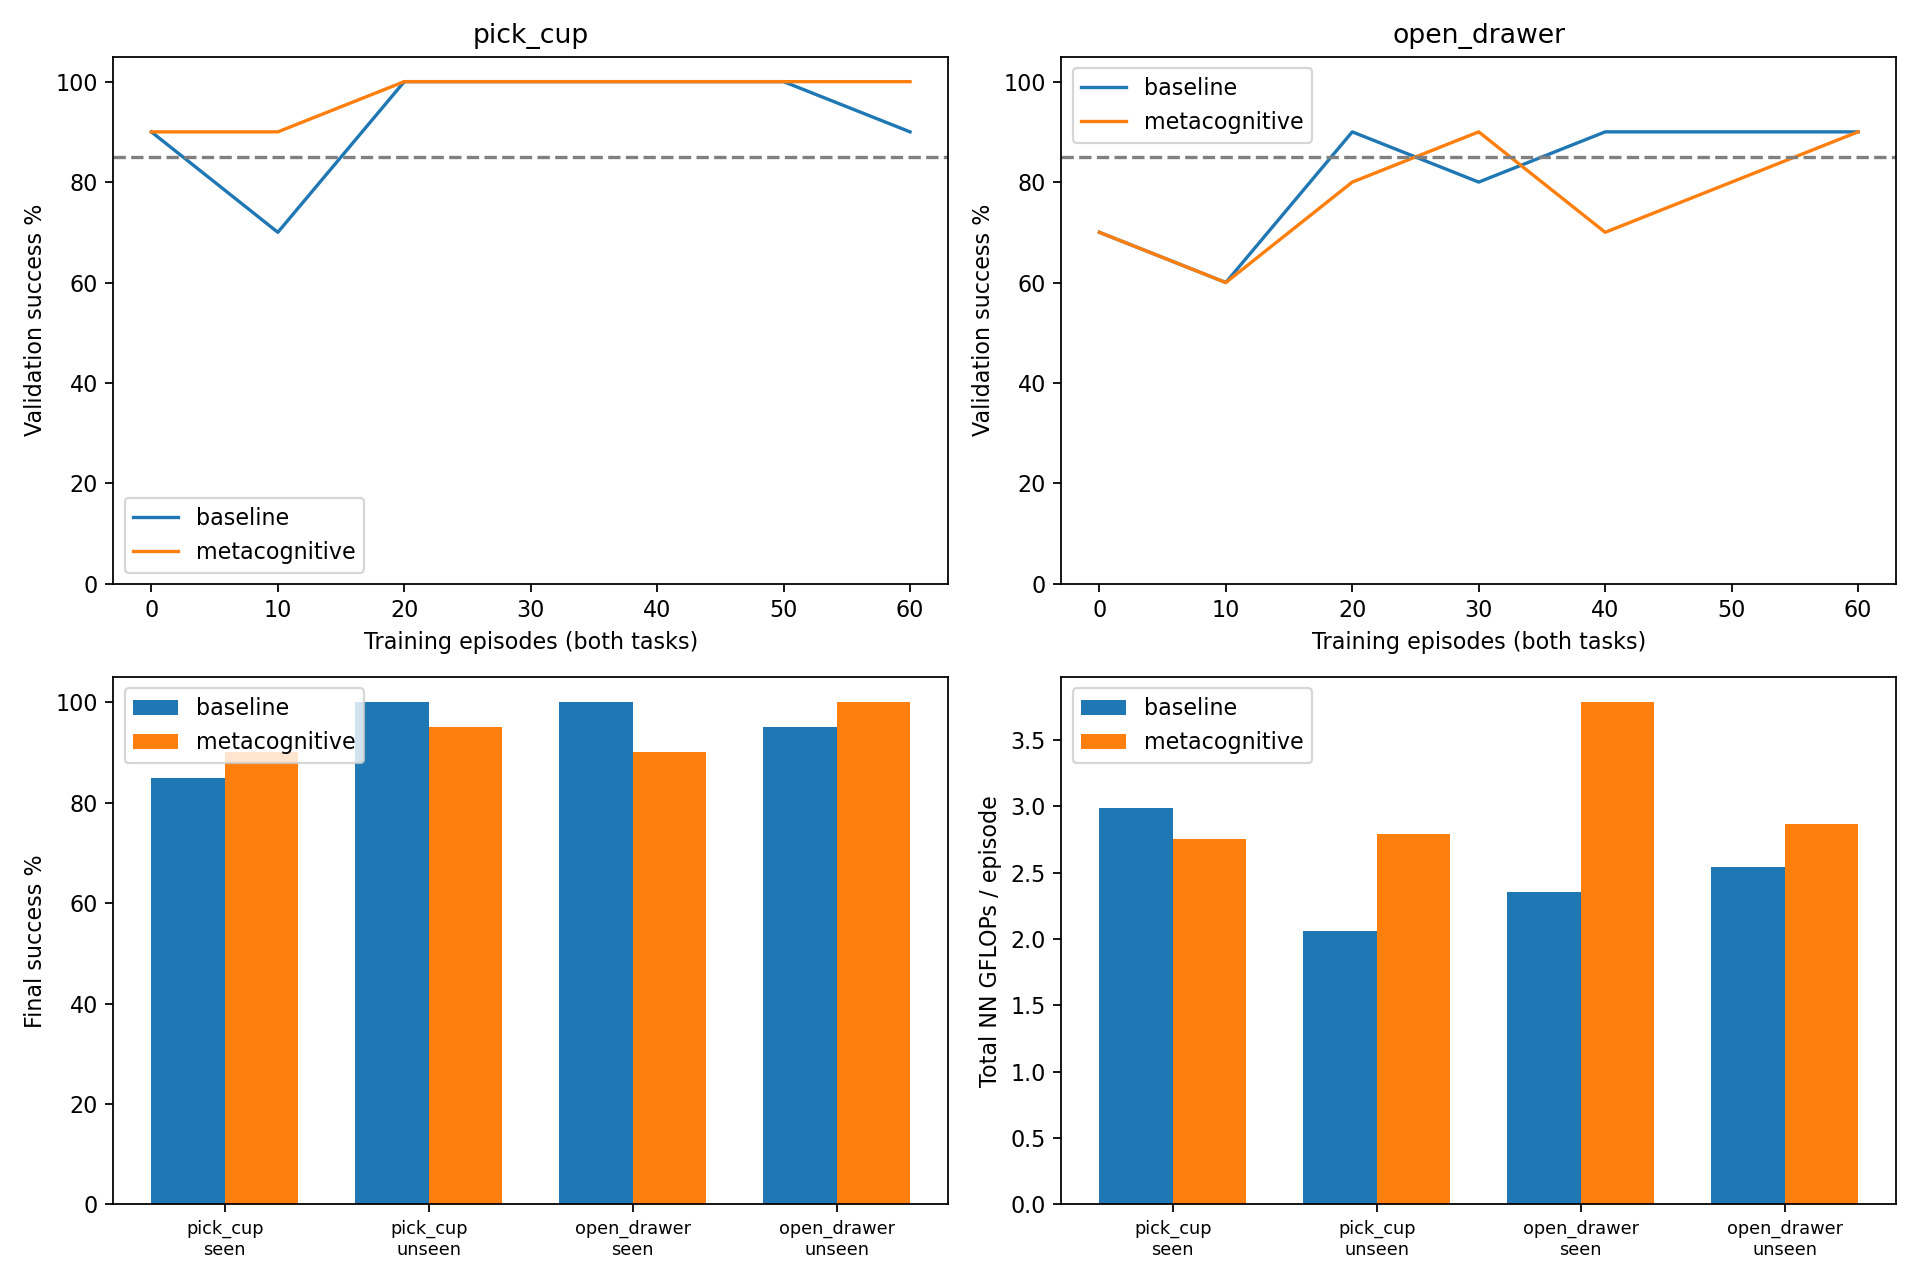

运行： /content/habitat_cup_demo/habitat-env/bin/python -m cup_baseline.aggregate --experiments /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0 /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1 --out /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/aggregate_learned_pilot
多 seed 汇总： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/aggregate_learned_pilot/aggregate.json 训练 seed 数： 2
aggregate_metrics.csv


,agent,task,split,metric,n_seeds,mean,std,n_defined_seeds
0,baseline,open_drawer,seen,collision_steps,2,3.650000,0.919239,2
1,baseline,open_drawer,seen,generalization_gap_pp,2,-2.500000,10.606602,2
2,baseline,open_drawer,seen,manipulation_collision_steps,2,0.000000,0.000000,2
3,baseline,open_drawer,seen,meta_gflops_episode,2,0.000000,0.000000,2
4,baseline,open_drawer,seen,nav_success_pct,2,97.500000,3.535534,2
...,...,...,...,...,...,...,...,...
83,metacognitive,pick_cup,unseen,nn_gflops_episode,2,2.637799,0.220262,2
84,metacognitive,pick_cup,unseen,nn_gflops_per_success,2,2.711314,0.324227,2
85,metacognitive,pick_cup,unseen,steps,2,54.875000,9.934850,2
86,metacognitive,pick_cup,unseen,steps_success_only,2,50.188158,3.306655,2


aggregate_paired.csv


,task,split,metric,n_seeds,mean,std,n_defined_seeds
0,open_drawer,seen,success_difference_pp,2,-5.000000,7.071068,2
1,open_drawer,seen,steps_difference,2,12.525000,18.349421,2
2,open_drawer,seen,nn_gflops_episode_difference,2,0.967054,0.651464,2
3,open_drawer,unseen,success_difference_pp,2,2.500000,3.535534,2
4,open_drawer,unseen,steps_difference,2,-3.075000,4.419417,2
5,open_drawer,unseen,nn_gflops_episode_difference,2,0.213173,0.149959,2
6,pick_cup,seen,success_difference_pp,2,5.000000,0.000000,2
7,pick_cup,seen,steps_difference,2,-16.525000,11.561196,2
8,pick_cup,seen,nn_gflops_episode_difference,2,-0.497189,0.376115,2
9,pick_cup,unseen,success_difference_pp,2,-2.500000,3.535534,2


aggregate_n85.csv


...

,agent,scope,domain,metric,n_seeds,mean,std,n_defined_seeds
0,baseline,all_training,NaN,episodes,2,120.000000,0.000000,2
1,baseline,all_training,NaN,steps,2,12124.000000,346.482323,2
2,baseline,all_training,NaN,total_gflops,2,591.444320,19.093190,2
3,baseline,all_training,NaN,meta_inference_gflops,2,0.000000,0.000000,2
4,baseline,all_training,NaN,meta_update_gflops,2,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...
79,metacognitive,initial_training,NaN,steps,2,4132.500000,321.733585,2
80,metacognitive,initial_training,NaN,total_gflops,2,213.704848,5.764157,2
81,metacognitive,initial_training,NaN,meta_inference_gflops,2,0.032604,0.008842,2
82,metacognitive,initial_training,NaN,meta_update_gflops,2,1.523371,0.000084,2


aggregate_calibration.csv


,task,split,metric,n_seeds,mean,std,n_defined_seeds
0,open_drawer,seen,baseline_fraction,2,0.084340,0.022366,2
1,open_drawer,seen,brier,2,0.096258,0.066368,2
2,open_drawer,seen,discrimination_auc,2,0.380289,0.016784,2
3,open_drawer,seen,ece,2,0.083728,0.058011,2
4,open_drawer,seen,execute_fraction,2,0.213147,0.014037,2
5,open_drawer,seen,expand_fraction,2,0.365653,0.484720,2
6,open_drawer,seen,high_confidence_failures,2,2.000000,1.414214,2
7,open_drawer,seen,high_confidence_n,2,20.000000,0.000000,2
8,open_drawer,seen,n,2,20.000000,0.000000,2
9,open_drawer,seen,restart_fraction,2,0.336859,0.476391,2


aggregate_local_monitoring.csv


,agent,task,split,diagnostic,metric,n_seeds,mean,std,n_defined_seeds
0,baseline,open_drawer,seen,collision.brier,value,2,NaN,NaN,0
1,baseline,open_drawer,seen,collision.discrimination_auc,value,2,NaN,NaN,0
2,baseline,open_drawer,seen,collision.ece,value,2,NaN,NaN,0
3,baseline,open_drawer,seen,collision.n,value,2,0.000000,0.000000,2
4,baseline,open_drawer,seen,n,value,2,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...
179,metacognitive,pick_cup,unseen,raw_phase.discrimination_auc,value,2,0.892560,NaN,1
180,metacognitive,pick_cup,unseen,raw_phase.ece,value,2,0.060371,0.052542,2
181,metacognitive,pick_cup,unseen,raw_phase.high_confidence_failures,value,2,12.000000,16.970563,2
182,metacognitive,pick_cup,unseen,raw_phase.high_confidence_n,value,2,771.000000,2.828427,2


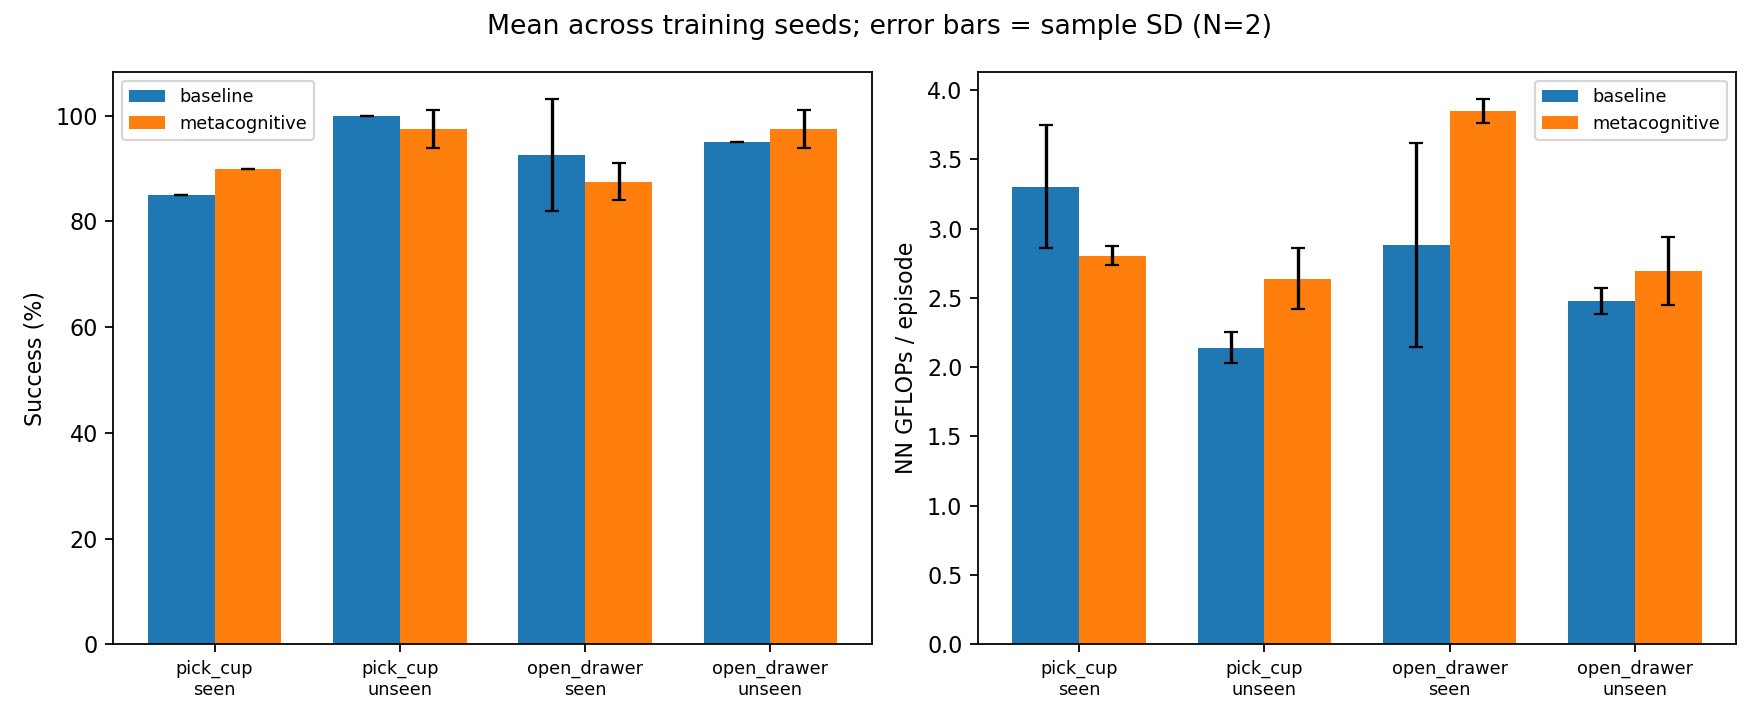

原始记录与单种子比较： [PosixPath('/content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed0'), PosixPath('/content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/meta_v2_learned_pilot_seed1')]
跨种子 CSV/JSON/PNG： /content/drive/MyDrive/HabitatHomeTwoTasks/outputs_meta_v2/aggregate_learned_pilot


In [11]:
def comparison_command(seed):
    run_dirs = RUN_DIRS_BY_SEED[seed]
    cl_dirs = CL_DIRS_BY_SEED[seed]
    return ['-m', 'cup_baseline.compare', '--baseline', run_dirs['baseline'],
            '--metacognitive', run_dirs['metacognitive'],
            '--baseline-cl', cl_dirs['baseline'], '--metacognitive-cl', cl_dirs['metacognitive'],
            '--out', EXPERIMENT_DIRS[seed] / 'comparison']

for seed in SEEDS:
    shadow_dir = EXPERIMENT_DIRS[seed] / 'shadow'
    run_habitat(['-m', 'cup_baseline.run', 'shadow', '--data', DATA,
                 '--out', shadow_dir,
                 '--checkpoint', RUN_DIRS_BY_SEED[seed]['baseline'] / 'checkpoint.pt',
                 '--monitor-checkpoint', RUN_DIRS_BY_SEED[seed]['metacognitive'] / 'checkpoint.pt',
                 '--n', SHADOW_N], f'shadow_meta_v2_seed{seed}')
    shadow = json.loads((shadow_dir / 'shadow_summary.json').read_text())
    print(f'共同轨迹监测诊断：seed={seed}；以下成本单独报告。')
    display(pd.DataFrame([shadow['costs']]))
    display(pd.read_csv(shadow_dir / 'shadow_metrics.csv'))
    run_habitat(comparison_command(seed), f'compare_meta_v2_seed{seed}')
    folder = EXPERIMENT_DIRS[seed] / 'comparison'
    report = json.loads((folder / 'comparison.json').read_text())
    print(f'\n种子 {seed}：基础指标')
    display(pd.DataFrame(report['metrics']))
    print('配对成功率差：metacognitive − baseline；单位为百分点。')
    display(pd.DataFrame(report['paired']))
    for agent, continual in report['continual'].items():
        for task in TASKS:
            print(f'{agent} · {TASK_LABELS[task]}：行=学完阶段，列=测试条件，单位=%')
            display(pd.DataFrame(continual['matrix'][task], index=DOMAIN_LABELS,
                                 columns=DOMAIN_LABELS).mul(100).round(1))
    for name in ['calibration.csv', 'local_monitoring.csv', 'continual_adaptation.csv',
                 'continual_retention.csv', 'continual_costs.csv', 'continual_paired.csv']:
        print(name)
        display(pd.read_csv(folder / name))
    display(Image(filename=str(folder / 'comparison.png')))

run_habitat(['-m', 'cup_baseline.aggregate', '--experiments',
             *[EXPERIMENT_DIRS[seed] for seed in SEEDS], '--out', AGGREGATE_DIR],
            'aggregate_meta_v2')
for name in ['aggregate_metrics.csv', 'aggregate_paired.csv', 'aggregate_n85.csv',
             'aggregate_continual.csv', 'aggregate_costs.csv', 'aggregate_calibration.csv',
             'aggregate_local_monitoring.csv']:
    print(name)
    display(pd.read_csv(AGGREGATE_DIR / name))
display(Image(filename=str(AGGREGATE_DIR / 'aggregate.png')))
print('原始记录与单种子比较：', list(EXPERIMENT_DIRS.values()))
print('跨种子 CSV/JSON/PNG：', AGGREGATE_DIR)

## 方法依据与解释边界

Guggenmos（2022）区分决策、元认知读出和信心转换，为“监测证据→分数→校准概率”的可诊断结构提供启发；Fleming & Daw（2017）讨论对自身决策过程的二阶推断。Desender 等（2018）研究信心与信息搜集的关系；Hamrick 等（2017）研究内部模拟的资源分配；van den Berg 等（2016）研究作出初始决定后的证据和改变决定。这里据此提出机器人监测/控制的工程实现，**不是这些论文的严格复现，也不主张拟合出了人类元认知噪声参数**。

详细结构、训练标签、校准隔离、计费边界与验证方法见源码 `METACOGNITION_zh.md`、`LOCAL_VALIDATION_zh.md`。环境采用结构化几何观测与辅助抓握，不是 RGB 视觉策略、真实力控或跨机器人泛化基准。本 notebook 只在完成真实实验后生成结果；本地测试替身的数字不作为 Habitat 成绩。

文献：[Guggenmos, 2022](https://elifesciences.org/articles/75420) · [Fleming & Daw, 2017](https://pubmed.ncbi.nlm.nih.gov/28004960/) · [Desender et al., 2018](https://pubmed.ncbi.nlm.nih.gov/29608411/) · [Hamrick et al., 2017](https://arxiv.org/abs/1705.02670) · [van den Berg et al., 2016](https://elifesciences.org/articles/12192)

## Cell 9 · 可选：录制实际执行视频（最后运行）

所有训练和指标完成后，再选择一个训练种子、一个 agent 和一个条件录像。默认使用其基础训练 checkpoint；这是一条定性示例，不代表平均成功率，不参与正式统计。本单元不重新训练模型。

如需录像，在 Colab 选择带 NVIDIA GPU 的运行时，并确认当前运行时能看到 GPU。切换运行时可能清空临时磁盘，先确保 checkpoint 已保存。脚本先检查实际图像帧是否可读，再录制；渲染失败保留诊断日志，不影响已完成的实验结果。

In [1]:
RECORD_VIDEO = False
VIDEO_SEED = SEEDS[0]
VIDEO_AGENT = 'metacognitive'  # 'baseline' 或 'metacognitive'。
VIDEO_DOMAIN = 0              # 0=A 原始环境，1=B 通道受阻，2=C 操作环境拥挤。
if RECORD_VIDEO:
    if VIDEO_SEED not in RUN_DIRS_BY_SEED or VIDEO_AGENT not in AGENTS:
        raise ValueError('请选择本次实验中已训练的 seed 和 agent。')
    if VIDEO_DOMAIN not in (0, 1, 2):
        raise ValueError('VIDEO_DOMAIN 必须为 0、1 或 2。')
    import runpy
    video_tools = runpy.run_path(str(CODE / 'record_video.py'))
    for task in TASKS:
        try:
            video_path = video_tools['repair_and_record'](
                CODE, PYTHON, DATA, RUN_DIRS_BY_SEED[VIDEO_SEED][VIDEO_AGENT],
                WORK, task=task, domain=VIDEO_DOMAIN)
            display(Video(str(video_path), embed=True))
        except Exception as error:
            print('录像未完成：', error)
            print('请检查渲染诊断；训练、持续学习和汇总结果已保留。')
else:
    print('已跳过可选录像。实验结果目录：', OUTPUT_ROOT)

NameError: name 'SEEDS' is not defined